In [8]:
from fp_gpu import *

x = hello
print(x())

sx: np.ndarray = sigmax()
sy: np.ndarray = sigmay()
sz: np.ndarray = sigmaz()

print("Sigma X:\n", sx)
print("Sigma Y:\n", sy)
print("Sigma Z:\n", sz)


# check equation:
left_side = sx @ sy
right_side = 1j * sz

if np.allclose(left_side, right_side):
    print("The equation σxσy = iσz holds.")
else:
    print("The equation σxσy = iσz does NOT hold.")

# uv venv
# source .venv/bin/activate
# uv pip install pip
# uv run --no-project pip install -e .
# python playground/test.py

Hello from fp-gpu!
Sigma X:
 [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
Sigma Y:
 [[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]
Sigma Z:
 [[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
The equation σxσy = iσz holds.


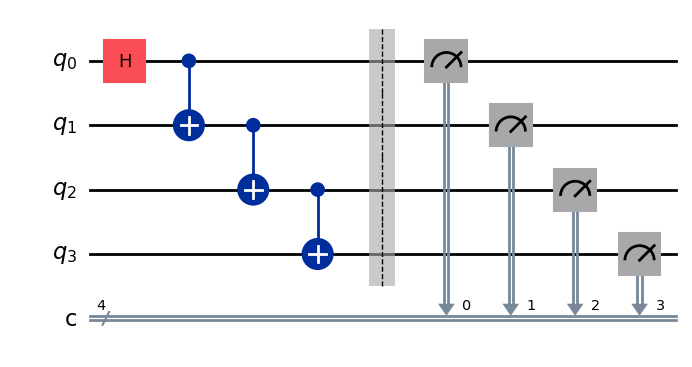

In [9]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit

bits = 4
qreg_q = QuantumRegister(bits + 1, "q")
creg_c = ClassicalRegister(bits, "c")
circuit = QuantumCircuit(qreg_q, creg_c)


circuit.h(qreg_q[0])
circuit.cx(qreg_q[0], qreg_q[1])
circuit.cx(qreg_q[1], qreg_q[2])
circuit.cx(qreg_q[2], qreg_q[3])

circuit.barrier()
circuit.measure(range(bits), range(bits))

circuit.draw(output="mpl", idle_wires=False, style="iqp")

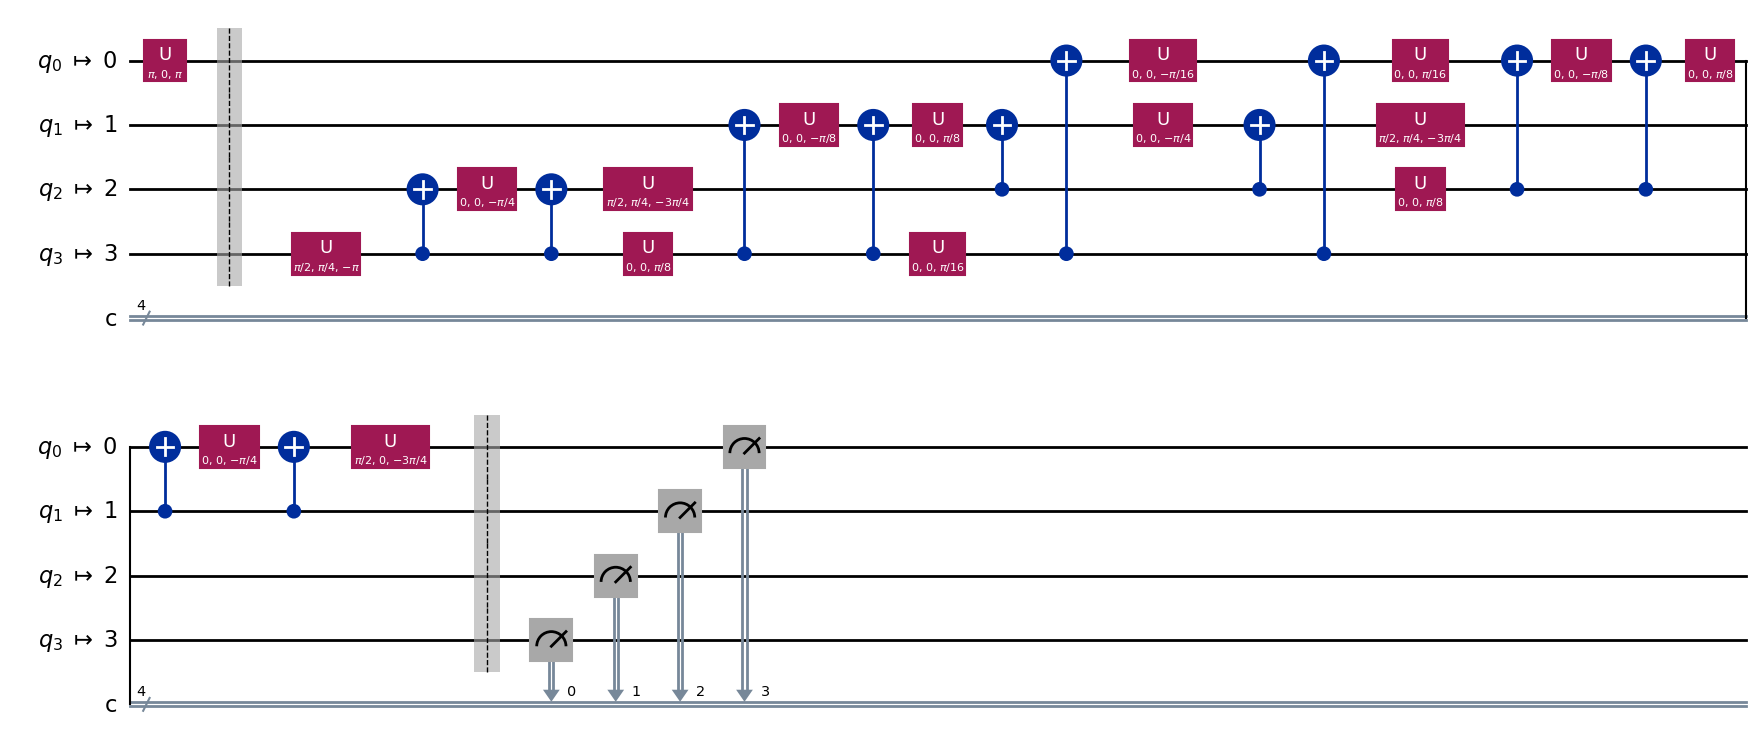

In [10]:
from qiskit.circuit.library import QFTGate
from qiskit import transpile

bits = 4
qreg_q = QuantumRegister(bits, "q")
creg_c = ClassicalRegister(bits, "c")
circuit = QuantumCircuit(qreg_q, creg_c)


circuit.x(qreg_q[0])


circuit.barrier()
circuit = circuit.compose(QFTGate(bits), [x for x in range(bits)])
circuit.barrier()
circuit.measure(range(bits), range(bits))
circuit = transpile(circuit, basis_gates=["u", "cx"])
circuit.draw(output="mpl", idle_wires=False, style="iqp")

{'1110': 77, '1001': 63, '1000': 54, '0010': 69, '1011': 61, '0101': 43, '0000': 77, '1010': 61, '0011': 64, '0001': 62, '0110': 61, '1100': 60, '0100': 75, '0111': 65, '1111': 54, '1101': 78}


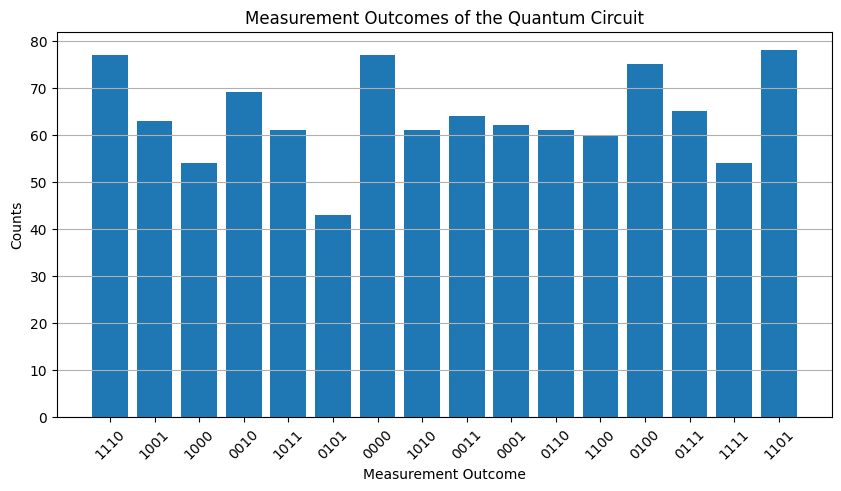

In [11]:
from qiskit_aer import AerSimulator, StatevectorSimulator
from matplotlib import pyplot as plt

simulator = AerSimulator()
compiled_circuit = transpile(circuit, simulator)
result = simulator.run(compiled_circuit, shots=1024).result()
counts = result.get_counts(compiled_circuit)
statevector = StatevectorSimulator().run(compiled_circuit).result().get_statevector()

print(counts)

plt.subplots(figsize=(10, 5))


plt.bar(counts.keys(), counts.values())
plt.xlabel("Measurement Outcome")
plt.ylabel("Counts")
plt.title("Measurement Outcomes of the Quantum Circuit")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [12]:
statevector.draw(output="latex", prefix="|ψ⟩ = ", max_size=10)

<IPython.core.display.Latex object>

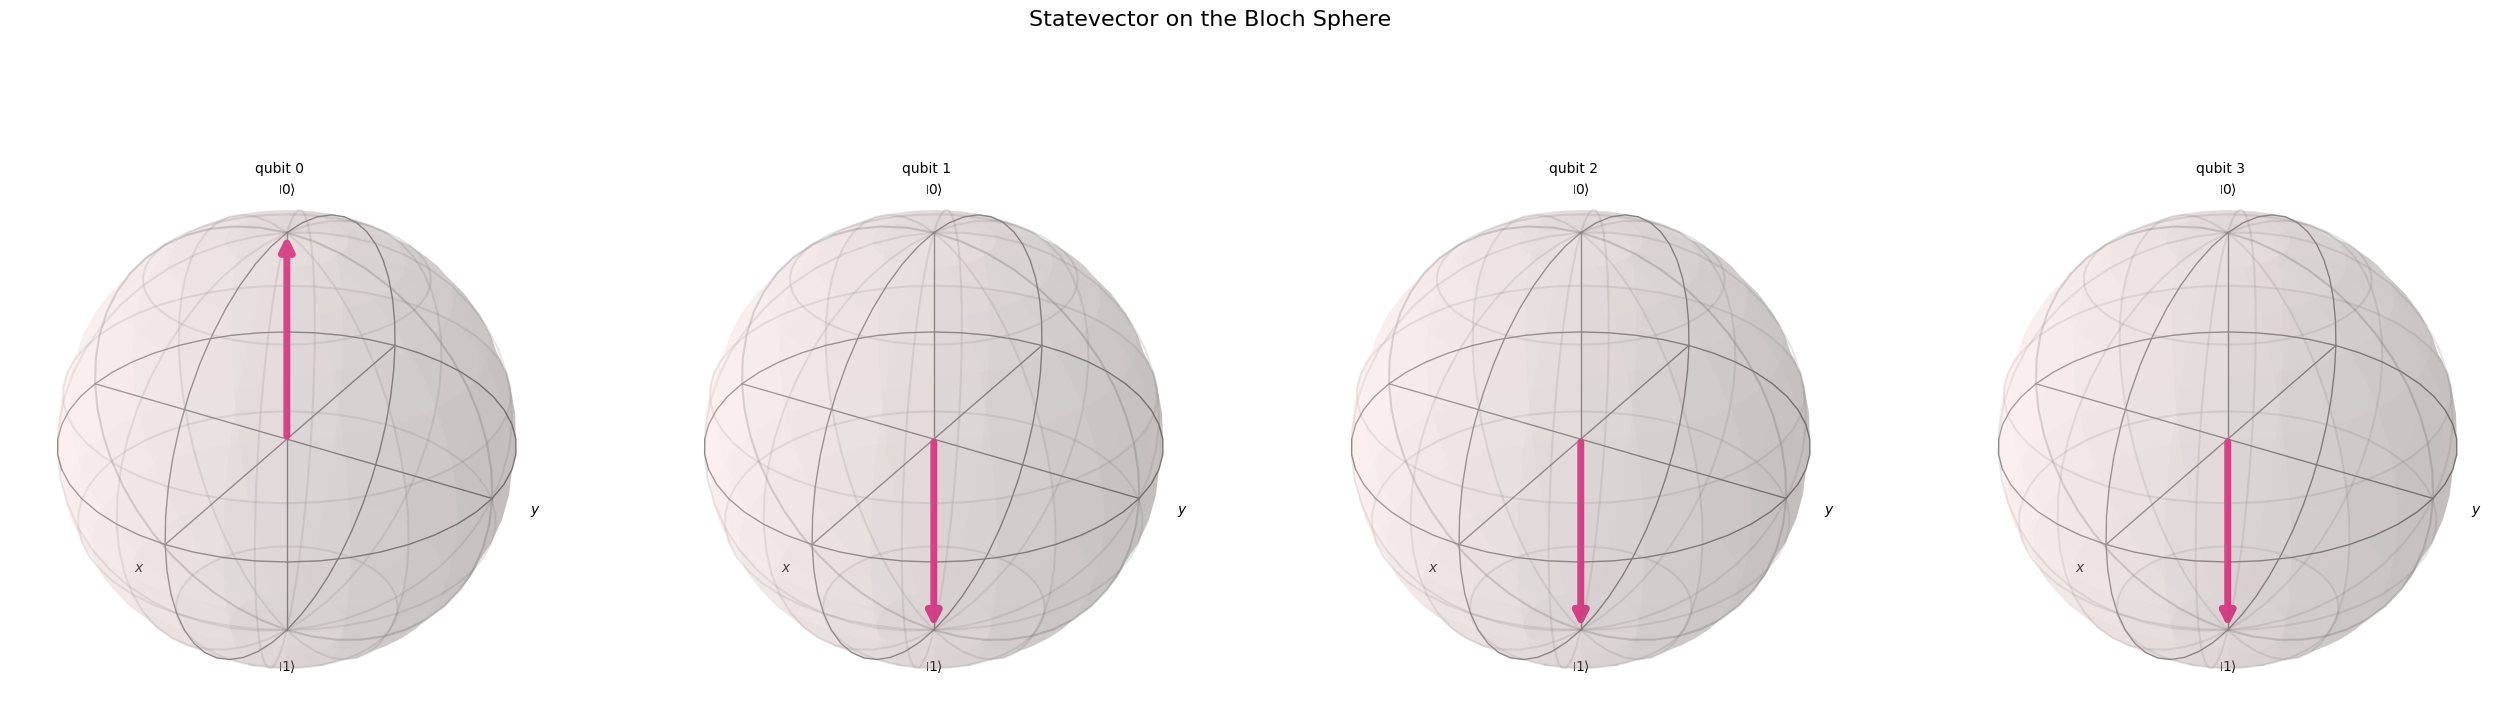

In [13]:
statevector.draw("bloch", title="Statevector on the Bloch Sphere", figsize=(8, 8))

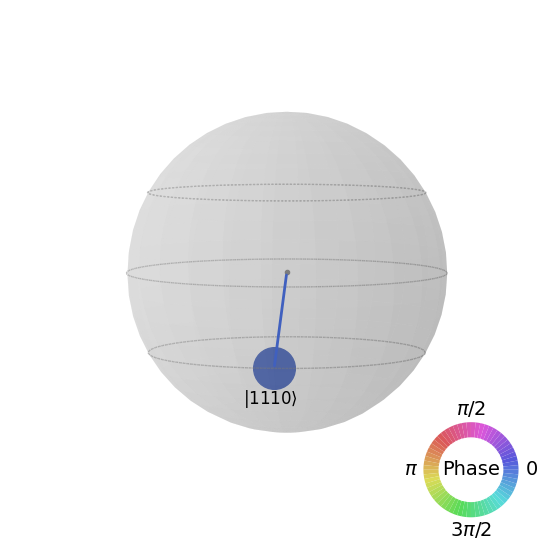

In [14]:
statevector.draw("qsphere")

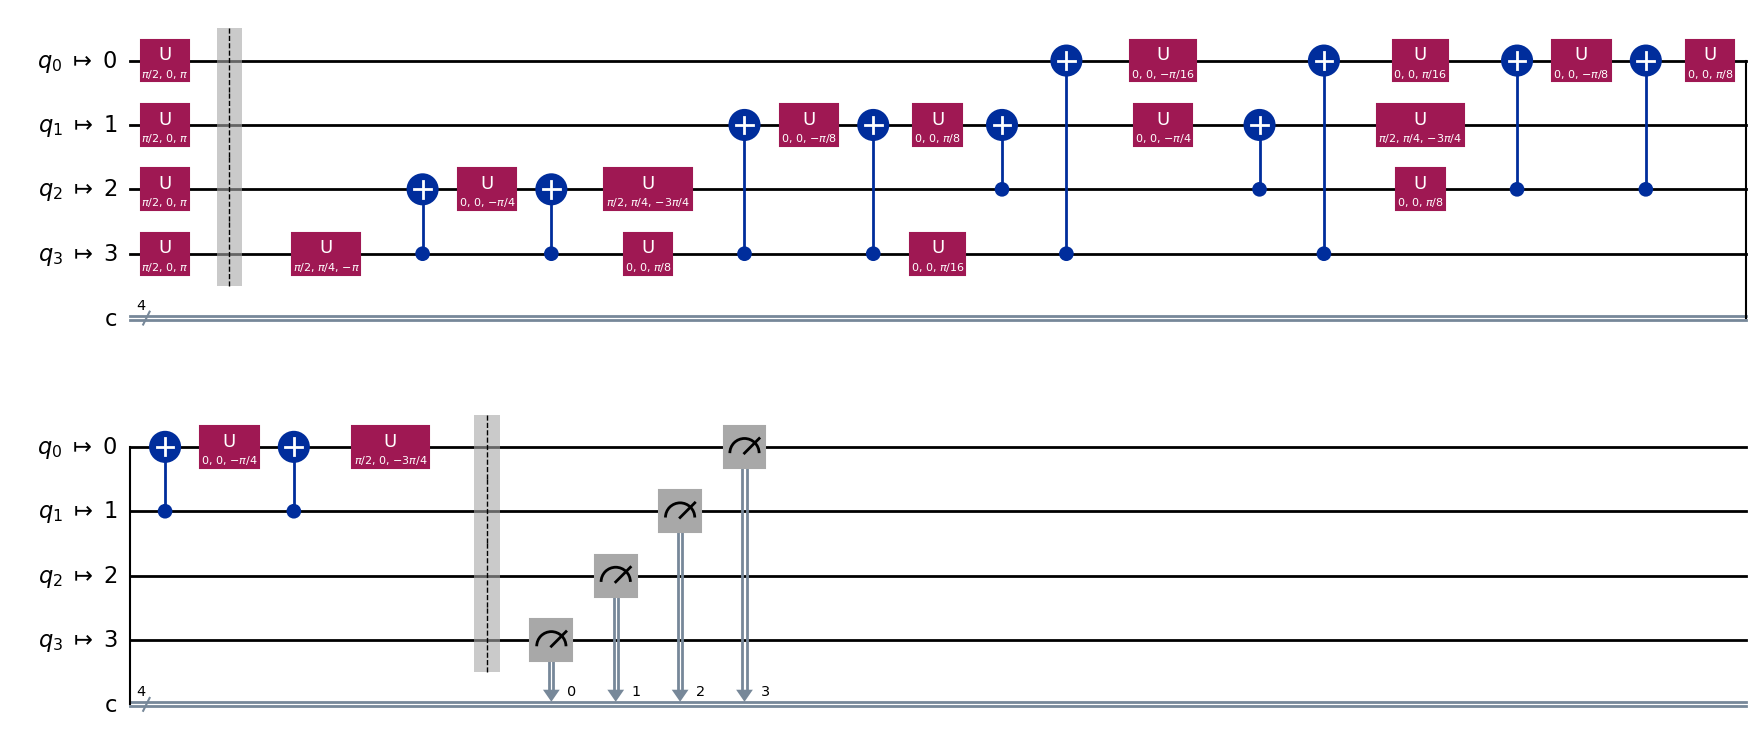

In [15]:
bits = 4
qreg_q = QuantumRegister(bits, "q")
creg_c = ClassicalRegister(bits, "c")
circuit = QuantumCircuit(qreg_q, creg_c)

for i in range(bits):
    circuit.h(qreg_q[i])


circuit.barrier()
circuit = circuit.compose(QFTGate(bits), [x for x in range(bits)])
circuit.barrier()
circuit.measure(range(bits), range(bits))
circuit = transpile(circuit, basis_gates=["u", "cx"])
circuit.draw(output="mpl", idle_wires=False, style="iqp")

{'0000': 1024}


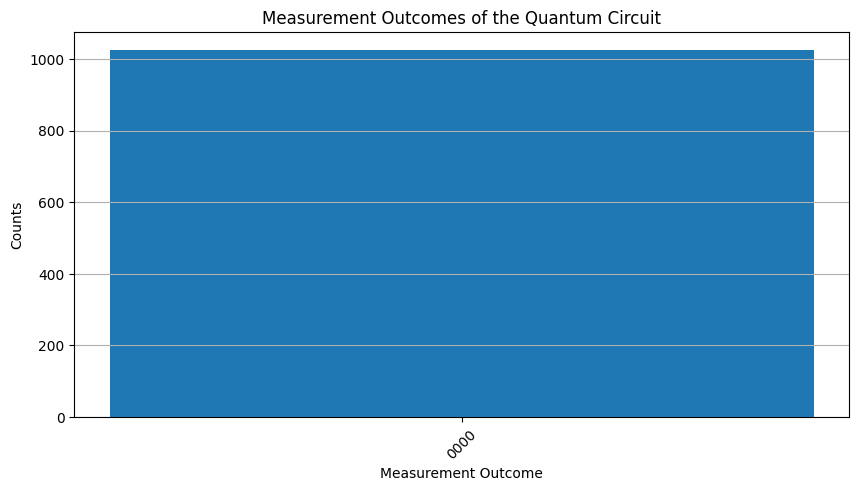

In [16]:
simulator = AerSimulator()
compiled_circuit = transpile(circuit, simulator)
result = simulator.run(compiled_circuit, shots=1024).result()
counts = result.get_counts(compiled_circuit)

print(counts)

plt.subplots(figsize=(10, 5))


plt.bar(counts.keys(), counts.values())
plt.xlabel("Measurement Outcome")
plt.ylabel("Counts")
plt.title("Measurement Outcomes of the Quantum Circuit")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()